# 🧬 Model Development – Immunotherapy Response Prediction
## Hackathon DIGPHAT-CANVAS – PharmacogenomicDay

**Use Case:** Multi-modal prediction of Immunotherapy response for ccRCC patients with follow-up post-Immune Checkpoint Blockade (ICB).

In this notebook we will:
1. Explore & integrate five omics/clinical modalities
2. Define the clinical outcome (RECIST response)
3. Preprocess each data modality (leakage-controlled)
4. Engineer features & reduce dimensionality
5. Train and evaluate multiple ML classifiers
6. Save the best model & preprocessing artifacts for the **Deployment Notebook**

In [31]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score,cross_validate, learning_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import miceforest as mf
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42

def plot_pca_2d(X_data, y_labels, title="2D PCA Projection", random_state=42):
    """
    Fits a 2D PCA on the provided features and plots the result colored by labels.
    
    Parameters:
    - X_data: DataFrame or array of features.
    - y_labels: Series or array of target labels (0 or 1).
    - title: String title for the plot.
    - random_state: Seed for reproducibility.
    """
    # Fit PCA with 2 components
    pca_2d = PCA(n_components=2, random_state=random_state)
    X_pca_2d = pca_2d.fit_transform(X_data)
    
    # Store results in a DataFrame for seaborn
    pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
    
    # Reset index to avoid misalignment if y_labels has an index
    if hasattr(y_labels, 'reset_index'):
        pca_df['Response'] = y_labels.reset_index(drop=True)
    else:
        pca_df['Response'] = y_labels

    # Create the scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='PC1', y='PC2', 
        hue='Response', 
        data=pca_df, 
        palette={0: 'darkorange', 1: 'steelblue'}, 
        alpha=0.7, 
        s=60
    )
    
    # Annotate with explained variance
    var_ratio = pca_2d.explained_variance_ratio_ * 100
    plt.xlabel(f'Principal Component 1 ({var_ratio[0]:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({var_ratio[1]:.1f}%)')
    plt.title(title)
    
    # Customize legend & styling
    plt.legend(title='Response (1=Responder)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

print("All imports OK ✅")

All imports OK ✅


---
# 1. Objective & Clinical Question

**Clinical question:** Can we predict RECIST response (CR/PR/SD vs PD) to immunotherapy from multi-modal patient data?

| Item | Detail |
|------|--------|
| Tumor type | Clear-cell Renal Cell Carcinoma (ccRCC) |
| Treatment | Immune Checkpoint Blockade (Nivolumab) |
| Outcome | Binary RECIST: **Responder** (CR/PR/SD) vs **Non-Responder** (PD) |
| Sites | Primary + metastatic samples |

---
# 2. Dataset Overview

## 2.1 Modalities

| # | Modality | Description |
|---|----------|-------------|
| 1 | **Clinical** | Demographics, treatment, tumour characteristics, RECIST |
| 2 | **Genomic** | Somatic mutations & copy-number alterations |
| 3 | **Immune deconvolution** | [CIBERSORTx](https://cibersortx.stanford.edu/) cell-type proportions from bulk RNA-seq |
| 4 | **Pathway scores** | ssGSEA scores for 50 [Hallmark pathways](https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=H) |
| 5 | **Transcriptomic** | Gene-level TPM expression (~40 k genes) |

---
The cohort is collected from the study by Braun et al. (2020) [Nature Medicine](https://www.nature.com/articles/s41591-020-0839-y) consisting of ccRCC patients treated with Nivolumab. We split the data into a training set (80%) and a hold-out test set (20%) for final evaluation.

- The **training set** → used in this notebook for model development (with cross-validation).
- The **test set** → held out for the **Deployment Notebook** (blind evaluation).

In [2]:
# ── Load all modalities ──────────────────────────────────────────────
nivo_clinical = pd.read_csv('Data/train_nivo/clinical.csv')
nivo_genomic  = pd.read_csv('Data/train_nivo/genomic.csv')
nivo_ssgsea   = pd.read_csv('Data/train_nivo/ssgsea.csv')
nivo_deconv   = pd.read_csv('Data/train_nivo/cell_deconvolution.csv')
nivo_transcriptomic = pd.read_csv('Data/train_nivo/transcriptomic.csv')

# ── Quick look at each modality ───────────────────────────────────────────────
for name, df in [('Clinical', nivo_clinical), ('Genomic', nivo_genomic),
                 ('Deconvolution', nivo_deconv), ('ssGSEA', nivo_ssgsea),
                 ('Transcriptomic', nivo_transcriptomic)]:
    print(f"\n{'='*60}")
    print(f"  {name}: Shape = {df.shape}")
    print(f"{'='*60}")
    display(df.head(3))


  Clinical: Shape = (137, 11)


,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,SD
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,PR
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,46.0,FAVORABLE,No,No,3.0,PRIMARY,SD



  Genomic: Shape = (137, 34)


,Patient_ID,Amplification_5q31.3,Amplification_5q35.3,Deletion_3p21.1,Deletion_6p22.2,Deletion_6p21.32,Deletion_6p12.1,Deletion_9p21.3,Deletion_9q34.3,Deletion_10q23.31,...,SETD2,SMARCA4,TCEB1,TP53,TRMT2B,TSC1,USP32,VHL,WNT8A,ZNF800
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,MUT,MUT,MUT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,MUT,WT,WT
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF



  Deconvolution: Shape = (137, 27)


,Patient_ID,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Absolute score (sig.score)
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.046327,0.086641,0.015842,0.185357,0.0,0.204351,0.022605,0.050186,0.009508,...,0.042027,0.021309,0.057458,0.0,0.009780,0.053686,0,0.923779,0.650795,1.274922
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.069083,0.050311,0.035438,0.101136,0.0,0.179168,0.035013,0.087914,0.000000,...,0.023344,0.019054,0.094429,0.0,0.000000,0.075189,0,0.917443,0.667743,1.304494
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,0.160051,0.012883,0.012708,0.202380,0.0,0.157942,0.091704,0.100219,0.000000,...,0.019324,0.017143,0.042158,0.0,0.001491,0.067586,0,0.915876,0.657080,1.417939



  ssGSEA: Shape = (137, 51)


,Patient_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.645208,0.613143,0.640741,0.544471,0.477824,0.356894,0.653818,0.393865,0.589824,...,0.792464,0.729333,0.128080,0.670299,0.571636,0.717934,0.662968,0.512491,0.432010,0.477736
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.745334,0.481716,0.692472,0.656193,0.583043,0.523270,0.671667,0.518503,0.672382,...,0.821810,0.773135,0.139733,0.745215,0.604999,0.734874,0.713620,0.574449,0.514951,0.629333
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,0.693889,0.433513,0.657505,0.449349,0.506846,0.336111,0.627200,0.462714,0.694758,...,0.821017,0.765573,0.189356,0.666627,0.503043,0.777414,0.591643,0.585362,0.419669,0.541380



  Transcriptomic: Shape = (137, 40935)


,Patient_ID,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,22.45228,34.75424,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,32.02459,32.43928,28.87370,29.40491,34.00210,21.13002,31.87140,31.90028,21.26386,28.67162
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,26.08813,33.57834,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,33.92360,33.17470,32.86634,32.95676,34.37301,21.13002,33.46758,32.99777,21.26386,33.29667
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,33.52886,32.94687,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,33.62518,29.16648,28.87370,29.40491,32.96280,21.13002,31.33387,32.84050,21.26386,28.67162


In [3]:
nivo_clinical_test = pd.read_csv('Data/test_nivo/clinical.csv')
nivo_genomic_test  = pd.read_csv('Data/test_nivo/genomic.csv')
nivo_ssgsea_test   = pd.read_csv('Data/test_nivo/ssgsea.csv')
nivo_deconv_test   = pd.read_csv('Data/test_nivo/cell_deconvolution.csv')
nivo_transcriptomic_test = pd.read_csv('Data/test_nivo/transcriptomic.csv')

In [4]:
nivo_transcriptomic_test

,Patient_ID,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,27.91941,34.70075,22.43516,21.04310,21.05360,21.01001,20.83447,22.39925,21.51332,...,34.67436,34.35974,33.35211,34.23558,34.75711,21.13002,33.69635,33.57917,21.26386,33.96374
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,22.45228,33.48258,22.43516,21.04310,21.05360,21.01001,25.69254,22.39925,21.51332,...,33.25229,32.88098,33.23512,34.18982,34.09013,21.13002,33.52007,33.08947,21.26386,32.90812
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,22.45228,34.02825,22.43516,21.04310,21.05360,21.01001,20.83447,22.39925,21.51332,...,27.94141,29.16648,28.87370,29.40491,32.73904,21.13002,30.58496,28.49402,21.26386,28.67162
3,G109543_RCCBMS-00007-T_v1_RNA_OnPrem,22.45228,34.40766,22.43516,21.04310,21.05360,21.01001,27.60613,22.39925,21.51332,...,32.12618,33.50541,33.59302,29.40491,32.34407,21.13002,28.92427,28.49402,21.26386,28.67162
4,G138701_RCCBMS-00093-T_v1_RNA_OnPrem,27.87479,32.86962,22.43516,21.04310,21.05360,21.01001,20.83447,22.39925,21.51332,...,33.10479,33.79387,33.89586,33.65025,34.44105,21.13002,33.20563,32.83498,21.26386,32.91102
5,G138701_RCCBMS-00028-T_v1_RNA_OnPrem,31.64839,34.06508,22.43516,21.04310,21.05360,21.01001,27.04569,22.39925,21.51332,...,33.04087,31.37365,33.35291,29.40491,32.72524,21.13002,32.50143,32.82149,21.26386,32.20392
6,G138701_RCCBMS-00125-T_v1_RNA_OnPrem,30.68037,35.22749,22.43516,21.04310,21.05360,21.01001,27.78492,22.39925,21.51332,...,30.54975,29.16648,33.46329,29.40491,32.41005,21.13002,31.86651,31.87446,21.26386,30.95966
7,G138701_RCCBMS-00165-T_v1_RNA_OnPrem,22.45228,34.71850,22.43516,21.04310,21.05360,21.01001,20.83447,22.39925,21.51332,...,27.94141,29.16648,28.87370,29.40491,31.58923,21.13002,29.47043,28.49402,21.26386,28.67162
8,G138701_RCCBMS-00036-T_v1_RNA_OnPrem,22.45228,33.70343,34.43395,21.04310,21.05360,21.01001,20.83447,22.39925,21.51332,...,33.69764,33.66044,32.47165,33.15826,33.90583,21.13002,32.35785,32.71414,21.26386,32.39673
9,G138701_RCCBMS-00103-T_v1_RNA_OnPrem,22.45228,32.88293,22.43516,21.04310,21.05360,21.01001,20.83447,22.39925,21.51332,...,32.47861,32.57528,28.87370,29.40491,32.17989,21.13002,31.35619,33.00673,21.26386,30.62134


## 2.2. Data Description

In [5]:
# ── Training data summary ────────────────────────────────────────────────────────────
print(f"Total patients: {len(nivo_clinical)}")
print(f"\nORR distribution:")
print(nivo_clinical['ORR'].value_counts().to_string())
print(f"\nCohorts: {nivo_clinical['Cohort'].unique()}")
print(f"Treatment arms: {nivo_clinical['Arm'].unique()}")

Total patients: 137

ORR distribution:
ORR
SD      53
PD      53
CRPR    22
PR       9

Cohorts: <ArrowStringArray>
['CM-010', 'CM-025', 'CM-009']
Length: 3, dtype: str
Treatment arms: <ArrowStringArray>
['NIVOLUMAB']
Length: 1, dtype: str


### 2.2.1. Outcome Definition
We define a **binary** outcome for immunotherapy response:
- **1 (Responder):** CR (Complete Response), PR (Partial Response), CRPR
- **0 (Non-Responder):** SD (Stable Disease), PD (Progressive Disease)

Response: {1: 84, 0: 53}  (ratio: 0.63:1)


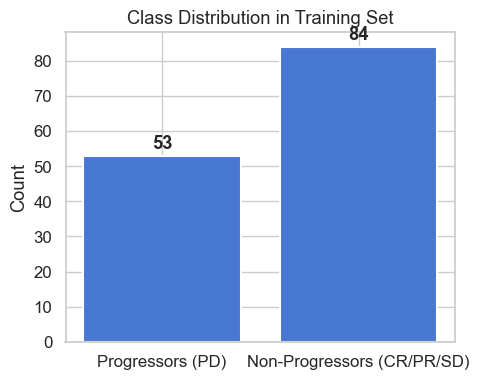

Progressors: 84  |  Non-Progressors: 53  |  Ratio: 1:0.6


In [6]:
# ── Map Response (RECIST) ────────────────────────────────────────────
response_map = {'CR': 1, 'PR': 1, 'CRPR': 1, 'SD': 1, 'PD': 0}
nivo_clinical['Response'] = nivo_clinical['ORR'].map(response_map)
y_nivo = nivo_clinical['Response'].values
print(f'Response: {pd.Series(y_nivo).value_counts().to_dict()}  (ratio: {(y_nivo==0).sum()/(y_nivo==1).sum():.2f}:1)')

resp_counts = nivo_clinical['Response'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Progressors (PD)', 'Non-Progressors (CR/PR/SD)'], resp_counts.values, edgecolor='white', linewidth=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_ylabel('Count'); ax.set_title('Class Distribution in Training Set')
plt.tight_layout(); plt.show()

ratio = resp_counts[1] / resp_counts[0]
print(f"Progressors: {resp_counts[1]}  |  Non-Progressors: {resp_counts[0]}  |  Ratio: 1:{1/ratio:.1f}")

### 2.2.2 Missing Data

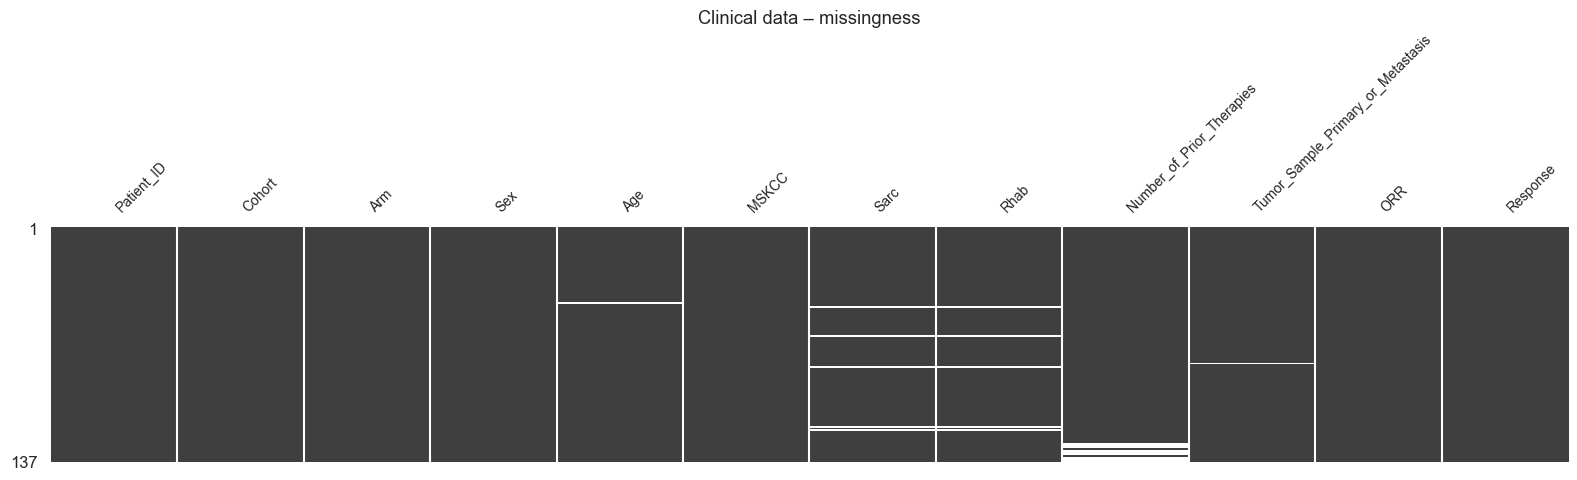

Total missing values in transcriptomic data: 0


In [7]:
fig, axes = plt.subplots(1,1, figsize=(16, 5))
msno.matrix(nivo_clinical, ax=axes, sparkline=False, fontsize=10)
axes.set_title('Clinical data – missingness')
plt.tight_layout()
plt.show()

print(f"Total missing values in transcriptomic data: {nivo_transcriptomic.isna().sum().sum()}")

# 3. Data Preprocessing & Feature Engineering

> **Leakage-controlled:** Every transformation (scaling, imputation, PCA, feature
> selection) is **fit on the training set only** and later applied to the test set
> in the Deployment Notebook.

## 3.1 Transcriptomic Data (RNA-seq)

The expression matrix contains **~40 000 genes** measured in **TPM** (Transcripts Per Million).

**Pre-processing steps:**
- The data is **already normalised to TPM**.
- We **filter low-expression genes** by removing genes below a variance threshold.
- We **standardise** the remaining genes.
- Sometimes, Gene identifiers are Ensembl IDs (e.g. `ENSG00000141510.18`).
  In a production pipeline you would convert them to HUGO symbols (`mygene` library, etc.). Here we keep Ensembl IDs for simplicity.

In [8]:
# ── 4.1  Transcriptomic processing ────────────────────────────────────────────
train_trans = nivo_transcriptomic.drop('Patient_ID', axis=1).copy()

# Filter low-expression genes  (under variance threshold)
gene_var = train_trans.var()
var_cutoff = 0.05 #we can also use quantile-based cutoff (e.g. top 50% variance)
keep_genes = gene_var[gene_var > var_cutoff].index.tolist()
nivo_transcriptomic_filtered = train_trans[keep_genes]
print(f"Genes kept after variance filter: {len(keep_genes)} / {len(gene_var)}")

print(f"Transcriptomic feature matrix: {nivo_transcriptomic_filtered.shape}")

Genes kept after variance filter: 37854 / 40934
Transcriptomic feature matrix: (137, 37854)


In [9]:
#Apply same gene filter to test set
test_transcriptomic_filtered = nivo_transcriptomic_test[keep_genes]

## 3.2 Clinical Data

### 3.2.1. Data encoding

- **Ordinal variables** (MSKCC, Number_of_Prior_Therapies) → ordinal encoding

- **Binary variables** (Sarc, Rhab, Sex, Tumor_Sample_Primary_or_Metastasis) → binary encoding

In [10]:
# ── 3.2 Clinical preprocessing ────────────
clinic = nivo_clinical.drop(columns=['Patient_ID', 'Cohort', 'Arm', 'ORR', 'Response']).copy()

# Replace NO_IF with NaN
for col in ['Sarc', 'Rhab', 'MSKCC']:
    clinic[col] = clinic[col].replace('NO_IF', np.nan)

# Initialize transformer dictionary for artifacts
transformers = {}

# 1. Binary encoding (Robust method for pandas Arrow types)
binary_cols = ['Sex', 'Sarc', 'Rhab', 'Tumor_Sample_Primary_or_Metastasis']
ordinal_cols = ['MSKCC','Number_of_Prior_Therapies']
num_cols = ['Age']
for col in binary_cols:
    le = LabelEncoder()
    mask = clinic[col].notna()
    vals = clinic.loc[mask, col].astype(str)
    encoded = le.fit_transform(vals)
    new_col = pd.Series(np.nan, index=clinic.index, dtype=float)
    new_col.loc[mask] = encoded.astype(float)
    clinic[col] = new_col
    transformers[f'le_{col}'] = le

# 2. Ordinal encoding for MSKCC
mskcc_map = {'POOR': 0, 'INTERMEDIATE': 1, 'FAVORABLE': 2}
clinic['MSKCC'] = clinic['MSKCC'].map(mskcc_map)
transformers['oe_MSKCC'] = mskcc_map

print(f"Encoders captured: {list(transformers.keys())}")

Encoders captured: ['le_Sex', 'le_Sarc', 'le_Rhab', 'le_Tumor_Sample_Primary_or_Metastasis', 'oe_MSKCC']


In [11]:
# ── 3.2 Clinical preprocessing ────────────
clinic_test = nivo_clinical_test.drop(columns=['Patient_ID', 'Cohort', 'Arm']).copy()

# Replace NO_IF with NaN
for col in ['Sarc', 'Rhab', 'MSKCC']:
    clinic_test[col] = clinic_test[col].replace('NO_IF', np.nan)


# 1. Binary encoding (Robust method for pandas Arrow types)
binary_cols = ['Sex', 'Sarc', 'Rhab', 'Tumor_Sample_Primary_or_Metastasis']
ordinal_cols = ['MSKCC','Number_of_Prior_Therapies']
num_cols = ['Age']
for col in binary_cols:
    le =  transformers[f'le_{col}']
    mask_test = clinic_test[col].notna()
    vals_test = clinic_test.loc[mask_test, col].astype(str)
    encoded_test = le.transform(vals_test)
    new_col_test = pd.Series(np.nan, index=clinic_test.index, dtype=float)
    new_col_test.loc[mask_test] = encoded_test.astype(float)
    clinic_test[col] = new_col_test

# 2. Ordinal encoding for MSKCC
clinic_test['MSKCC'] = clinic_test['MSKCC'].map(mskcc_map)



Missing values before imputation: 54


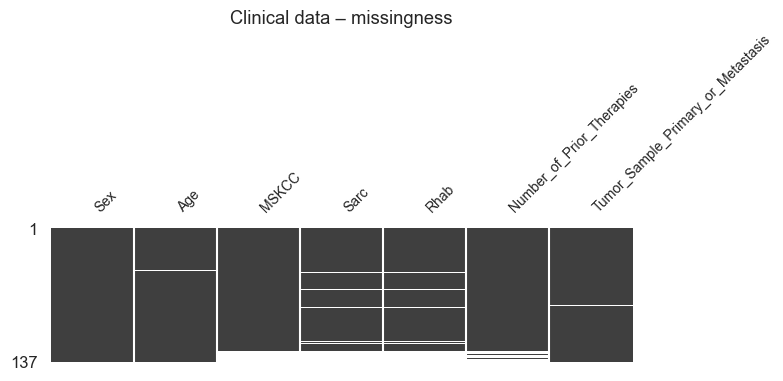

In [12]:
# Before imputing
missing_before = clinic.isna().sum().sum()
print(f"Missing values before imputation: {missing_before}")
#Visualize missingness in clinical data 
fig, ax = plt.subplots(figsize=(8, 4))
msno.matrix(clinic, ax=ax, sparkline=False, fontsize=10)
plt.title('Clinical data – missingness')
plt.tight_layout()
plt.show()  

### 3.2.2. Handling Missing Values in Clinical Data

We impute missing values using **MICE** (Multiple Imputation by Chained Equations) via the `miceforest` library.

In [13]:
clinic_for_mice = clinic.copy()
clinic_for_mice = clinic_for_mice.astype(float)

# MICE imputation (NO Response in the imputation)
kernel_nivo = mf.ImputationKernel(clinic_for_mice, random_state=RANDOM_STATE)   
kernel_nivo.mice(iterations=10, verbose=False)
nivo_clinical_imputed = kernel_nivo.complete_data()


print(f'Clinical imputed shape: {nivo_clinical_imputed.shape}')
print(f'Missing after MICE: {nivo_clinical_imputed.isna().sum().sum()}')

Clinical imputed shape: (137, 7)
Missing after MICE: 0


In [14]:
clinic_for_mice_test = clinic_test.copy()
clinic_for_mice_test = clinic_for_mice_test.astype(float)

test_imputed = kernel_nivo.impute_new_data(clinic_for_mice_test).complete_data()


print(f'Clinical imputed shape: {clinic_test.shape}')
print(f'Missing after MICE: {test_imputed.isna().sum().sum()}')

Clinical imputed shape: (35, 7)
Missing after MICE: 0


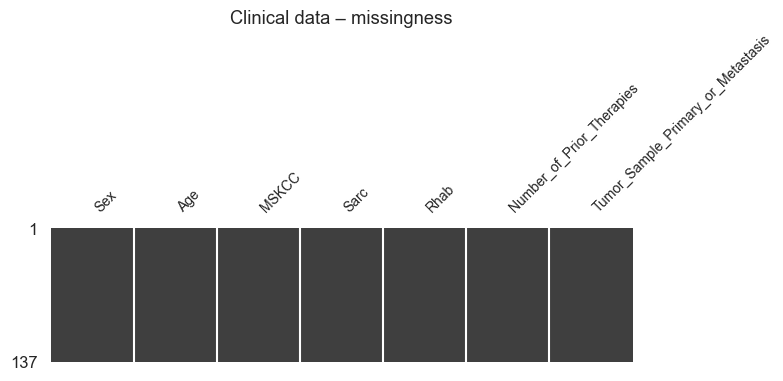

In [15]:
#Visualize missingness in clinical data 
fig, ax = plt.subplots(figsize=(8, 4))
msno.matrix(nivo_clinical_imputed, ax=ax, sparkline=False, fontsize=10)
plt.title('Clinical data – missingness')
plt.tight_layout()
plt.show()  

## 3.3 Somatic Mutation Data


The genomic dataset contains somatic **mutation status** and **copy-number alterations**.

Values: `MUT` (mutated) / `WT` (wild-type) / **`NO_IF`** (no information).

We can treat these as categorical features, but we need to handle the `NO_IF` values carefully. We can consider it as missing values or as a separate category depending on the context. Here, we assume `NO_IF` patients as `WT` and add a new proxy column **`tmb_proxy`** (calculated as the sum of mutations per patient) to capture a signal similar to Tumor Mutational Burden. Additionally, we use a binary indicator **`has_genomic_data`** to explicitly flag samples where data was missing, and we remove non-informative features with zero variance across the cohort.

In [16]:
# ── Genomic encoding ─────────────────────────────────────────────────
nivo_gen = nivo_genomic.set_index('Patient_ID')
nivo_gen_encoded = nivo_gen.replace({'MUT': 1, 'WT': 0, 'NO_IF': np.nan}).astype(float)

# TMB proxy: count of mutations per patient (before filling NaN)
tmb_proxy = nivo_gen_encoded.sum(axis=1)

# has_genomic_data indicator
has_genomic = (~nivo_gen_encoded.isna().all(axis=1)).astype(int)
nivo_gen_encoded['has_genomic_data'] = has_genomic
nivo_gen_encoded['tmb_proxy'] = tmb_proxy

# Fill NaN with 0 (WT default)
nivo_genomic_filled = nivo_gen_encoded.fillna(0).reset_index(drop=True)

# Remove zero-variance genomic columns (no information)
zero_var_cols = nivo_genomic_filled.columns[nivo_genomic_filled.var() == 0].tolist()
if zero_var_cols:
    print(f'Removing {len(zero_var_cols)} zero-variance genomic columns: {zero_var_cols}')
    nivo_genomic_filled = nivo_genomic_filled.drop(columns=zero_var_cols)
print(f'Genomic shape: {nivo_genomic_filled.shape}')

Removing 7 zero-variance genomic columns: ['COL9A3', 'PCK1', 'PIK3CA', 'SMARCA4', 'TCEB1', 'TRMT2B', 'WNT8A']
Genomic shape: (137, 28)


In [17]:
test_gen = nivo_genomic_test.set_index('Patient_ID').replace({'MUT':1, 'WT':0, 'NO_IF':np.nan}).astype(float)
test_gen['tmb_proxy'] = test_gen.sum(axis=1)
test_gen['has_genomic_data'] = (~test_gen.isna().all(axis=1)).astype(int)
test_gen_filled = test_gen.fillna(0)

test_gen_final = test_gen_filled[nivo_genomic_filled.columns].reset_index(drop=True)

## 3.4 ssGSEA Pathway Scores (Hallmark)

50 Hallmark pathway enrichment scores computed with [GSEAPy](https://gseapy.readthedocs.io/).
```python
import gseapy as gp
# txt, gct file input
ss = gp.ssgsea(data='./tests/extdata/Leukemia_hgu95av2.trim.txt',
               gene_sets='./tests/extdata/h.all.v7.0.symbols.gmt',
               outdir=None,
               sample_norm_method='rank', # choose 'custom' will only use the raw value of `data`
               no_plot=True)
```

In [18]:
# ── Pathway (ssGSEA) ────────────────────────────────────────────────
nivo_pathway = nivo_ssgsea.drop('Patient_ID', axis=1).copy()
print(f'Pathway features: {nivo_pathway.shape[1]}')

nivo_pathway_test =  nivo_ssgsea_test.drop('Patient_ID', axis=1).copy()

Pathway features: 50


## 3.5 Immune Cell Deconvolution (CIBERSORTx)

Cell-type proportions estimated from bulk RNA-seq. We leverage the [CIBERSORTx](https://cibersortx.stanford.edu/) tool to deconvolve bulk transcriptomic data into immune cell-type proportions. The output consists of relative abundances of various immune cell types (e.g., CD8+ T cells, macrophages, etc.) for each sample. 

We used LM22 signature matrix for deconvolution, which includes 22 immune cell types. The resulting cell-type proportions are compositional data (i.e., they sum to 1 for each sample).

Since these are **compositional data** (proportions summing to ~1), we apply a **centered-logratio (CLR) transform**.

In [19]:
cell_cols = [
    c for c in nivo_deconv.columns
    if c not in ["Patient_ID", "P-value", "Correlation", "RMSE", "Absolute score (sig.score)"]
]

X = nivo_deconv[cell_cols].copy()

# Small epsilon to avoid log(0)
eps = 1e-6
X_eps = X + eps

# Geometric mean per sample (row)
geo_mean = np.exp(np.log(X_eps).mean(axis=1))

# CLR: log(x / g(x)) for each row
clr_values = np.log(X_eps.div(geo_mean, axis=0))
nivo_deconv_clr = pd.DataFrame(clr_values, columns=cell_cols)


display(nivo_deconv_clr.head(3))

,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Monocytes,Macrophages M0,Macrophages M1,Macrophages M2,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils
0,1.106195,1.732235,0.033161,2.492746,-9.637300,2.590298,0.388685,1.186221,-0.477278,0.434806,...,0.886214,0.752443,1.644273,2.775600,1.008799,0.329645,1.321521,-9.637300,-0.449077,1.253634
1,2.707152,2.390075,2.039648,3.088306,-8.435925,3.660157,2.027585,2.948201,-8.435925,0.078075,...,3.233167,-8.435925,2.851695,3.936390,1.622233,1.419137,3.019691,-8.435925,-8.435925,2.791843
2,3.333933,0.814407,0.800731,3.568584,-8.649322,3.320670,2.777016,2.865796,-8.649322,-8.649322,...,2.862066,-0.909544,2.798038,3.850994,1.219826,1.100090,1.999874,-8.649322,-1.341376,2.471848


In [20]:
# ── 3.3  Immune deconvolution: CLR transform + scaling ────────────────────────
test_deconv_raw = nivo_deconv_test[cell_cols].copy()

# CLR transform (same logic as training)
eps = 1e-6
X_eps = test_deconv_raw + eps
geo_mean = np.exp(np.log(X_eps).mean(axis=1))
clr_values = np.log(X_eps.div(geo_mean, axis=0))

# Scale with the fitted StandardScaler
test_deconv_clr = pd.DataFrame(
    clr_values,
    columns=cell_cols
)
print(f"Immune deconv → {test_deconv_clr.shape[1]} features")

Immune deconv → 22 features


## **3.6. Integrate all preprocessed features**

In [21]:
X_full = pd.concat([
    nivo_clinical_imputed.reset_index(drop=True),
    nivo_pathway.reset_index(drop=True),
    nivo_deconv_clr.reset_index(drop=True),
    nivo_genomic_filled.reset_index(drop=True),
    nivo_transcriptomic_filtered.reset_index(drop=True)
], axis=1)

In [22]:
# ── 3.5 Combine all modalities ──────────
X_full_test = pd.concat([
    test_imputed.reset_index(drop=True),
    nivo_pathway_test.reset_index(drop=True),
    test_deconv_clr.reset_index(drop=True),
    test_gen_final,
    test_transcriptomic_filtered.reset_index(drop=True)
], axis=1)

# **4. Baseline model**

## **4.1. Cross Validation**

In [23]:
scaler_tmp = MinMaxScaler()
X_scaled_tmp = scaler_tmp.fit_transform(X_full)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

scoring = {
    'roc_auc':   'roc_auc',
    'pr_auc':   'average_precision',
    'f1':        'f1',
}

logit = LogisticRegression(penalty='l2', max_iter=2000, random_state=RANDOM_STATE)
for score in scoring.values():
    # Note we use X_train_final here instead of X_train_sel so feature selection happens inside CV
    cv_res = cross_val_score(logit, X_scaled_tmp, y_nivo, cv=cv, scoring=score, n_jobs=-1)
    print(f"{score:25s}  {cv_res.mean():.3f}±{cv_res.std():.3f}")

roc_auc                    0.447±0.077
average_precision          0.621±0.073
f1                         0.688±0.048


In [24]:
y_true_df = pd.read_csv('Data/test_nivo/y_test_labels.csv')
y_true = y_true_df['Response'].values

logit.fit(X_full, y_nivo)
y_pred = logit.predict(X_full_test)
y_proba = logit.predict_proba(X_full_test)[:, 1]

print(f"ROC: {roc_auc_score(y_true, y_proba)}")
print(f"PR AUC: {average_precision_score(y_true, y_proba)}")

ROC: 0.4217687074829932
PR AUC: 0.5608308257949299


## **4.2. Learning Curves**
A learning curve helps diagnose **overfitting** (large train–test gap) and
**underfitting** (both curves plateau at low score).

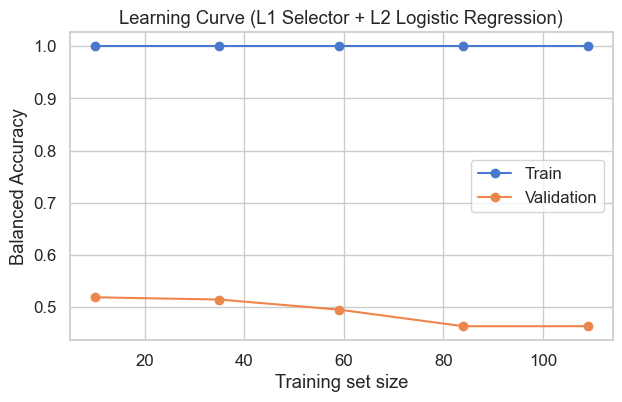

In [25]:
# ── 4.2 Learning curves (baseline) ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
train_sizes, train_scores, val_scores = learning_curve(
    logit, X_scaled_tmp, y_nivo, cv=cv, scoring='balanced_accuracy',
    n_jobs=-1, random_state=RANDOM_STATE)

ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
ax.set_xlabel('Training set size'); ax.set_ylabel('Balanced Accuracy')
ax.legend()
plt.title('Learning Curve (L1 Selector + L2 Logistic Regression)')
plt.show()

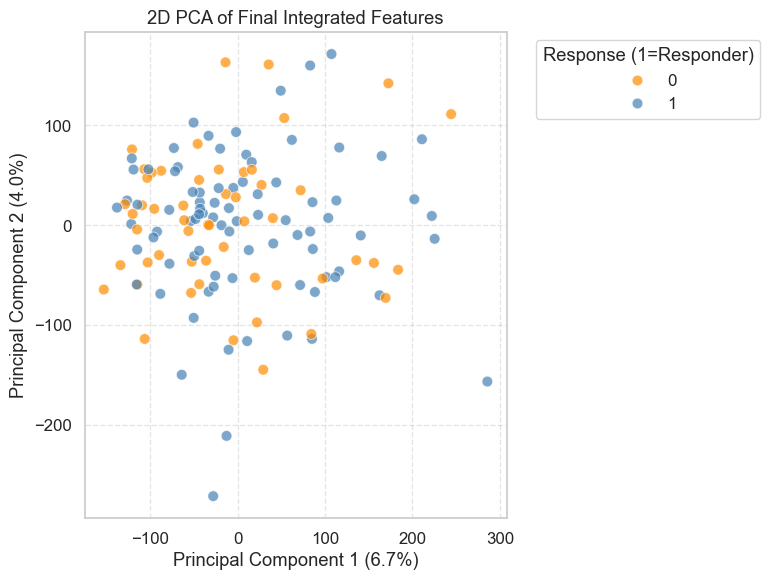

In [27]:
plot_pca_2d(X_full, y_nivo, title="2D PCA of Final Integrated Features")

# **5. Model Developement**

## **5.1. Feature Selection & Dimensionality Reduction**


## **5.1.1. Filter Methods: ANOVA F-test**
We use the **ANOVA F-test** via `SelectKBest` to perform univariate feature selection. This method evaluates the linear relationship between each numerical numerical feature and the categorical target, selecting the top $k$ features with the strongest statistical significance.

```python
from sklearn.feature_selection import SelectKBest, f_classif

# k is the number of features you want to keep
selector = SelectKBest(score_func=f_classif, k=20)

X_train_sel = selector.fit_transform(X_train_final, y_train)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")
```

---

## **5.1.2. Filter Methods: Mutual Information**
We utilize **Mutual Information (MI)** to capture both linear and non-linear dependencies between features and the target. Unlike the F-test, MI measures information gain, making it more robust for identifying complex biological signals that do not follow a simple linear trend.

```python
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from functools import partial

# We fix the random state because MI has a stochastic component (internal KNN)
mi_func = partial(mutual_info_classif, random_state=RANDOM_STATE)
selector = SelectKBest(score_func=mi_func, k=20)

X_train_sel = selector.fit_transform(X_train_final, y_train)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")
```

## **5.1.3. Embedded Methods**
We use **Logistic Regression** to perform embedded feature selection. The `SelectFromModel` class from `sklearn` allows us to select features based on the importance weights learned by the logistic regression model.

```python
model = LogisticRegression(random_state=RANDOM_STATE)
selector = SelectFromModel(model, prefit = False)

X_train_sel = selector.fit_transform(X_train_final, y_train)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")
```

## **5.1.4. Wrapper Methods**
We can also use **Recursive Feature Elimination (RFE)** with a logistic regression estimator to iteratively select features by recursively considering smaller and smaller sets of features.

```python
from sklearn.feature_selection import RFE
estimator = LogisticRegression(random_state=RANDOM_STATE)
selector = RFE(estimator, n_features_to_select=20, step=1)
selector = selector.fit(X_train_final, y_train)
X_train_sel = selector.transform(X_train_final)
```

## **5.2. Dimensionality Reduction with PCA**
We can apply **Principal Component Analysis (PCA)** to reduce the dimensionality of the transcriptomic features while retaining most of the variance. We can select the number of principal components based on the cumulative explained variance (e.g., retaining 95% of the variance).
```python
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_result = pca.fit_transform(X_train_transcriptomic_scaled) 
```

In [28]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_result = pca.fit_transform(nivo_transcriptomic_filtered)
n_pcs = train_pca_result.shape[1]
pca_columns = [f'PC{i+1}' for i in range(n_pcs)]
train_pca_df = pd.DataFrame(
    train_pca_result, 
    columns=pca_columns,
    index=nivo_transcriptomic_filtered.index)

X_pca = pd.concat([
    nivo_clinical_imputed.reset_index(drop=True),
    nivo_pathway.reset_index(drop=True),
    nivo_deconv_clr.reset_index(drop=True),
    nivo_genomic_filled.reset_index(drop=True),
    train_pca_df.reset_index(drop=True)
], axis=1)

display(X_pca.head(3))


#Apply PCA transform to test set
test_pca_results = pca.transform(test_transcriptomic_filtered)

test_pca_df = pd.DataFrame(
    test_pca_results, 
    columns=pca_columns,
    index=test_transcriptomic_filtered.index)

X_pca_test = pd.concat([
    test_imputed.reset_index(drop=True),
    nivo_pathway_test.reset_index(drop=True),
    test_deconv_clr.reset_index(drop=True),
    test_gen_final,
    test_pca_df.reset_index(drop=True)
], axis=1)


,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,...,PC111,PC112,PC113,PC114,PC115,PC116,PC117,PC118,PC119,PC120
0,1.0,62.0,2.0,0.0,0.0,2.0,1.0,0.645208,0.613143,0.640741,...,3.841456,-2.039303,-2.367983,-8.957108,-7.430105,3.156943,-0.982372,-6.713445,-5.127768,9.902307
1,0.0,62.0,0.0,0.0,0.0,1.0,1.0,0.745334,0.481716,0.692472,...,-7.375115,4.260842,0.964560,2.912280,-8.135050,-18.795439,3.212422,-10.876446,-9.943256,2.087991
2,0.0,46.0,2.0,0.0,0.0,3.0,1.0,0.693889,0.433513,0.657505,...,5.455867,4.852115,9.615292,-2.057968,0.288815,9.372104,-3.583604,2.396335,2.073483,-9.164006


## **5.3. Data Sampling**

### **5.3.1. Oversampling**

- **Oversampling** aims to balance the dataset by increasing the number of samples in the minority class. The simplest form is **Random Oversampling**, which duplicates existing minority instances. While this balances the class distribution, it carries a high risk of **overfitting**, as the model essentially "memorizes" specific data points rather than learning general patterns.

- **SMOTE** is a more sophisticated "informed" oversampling technique. Instead of duplicating rows, it selects a minority class point and identifies its $k$-nearest neighbors. It then creates **synthetic** data points along the line segments connecting these neighbors. This "stretches" the minority class region, helping the model learn a more robust decision boundary and reducing the likelihood of overfitting.

- **ADASYN** builds upon the SMOTE concept but adds an **adaptive** mechanism. It focuses on the "hard-to-learn" parts of the feature space. ADASYN looks for minority samples that are surrounded by many majority class points (the "borderline" or "noisy" areas) and generates more synthetic data there. This forces the model to pay more attention to the most difficult areas where the classes overlap, rather than wasting resources on "easy" areas.

### **5.3.2. Undersampling**

- **Undersampling** balances the dataset by removing instances from the majority class. This is often used when you have a massive dataset and want to reduce computational costs. However, the major drawback is **information loss**—you might discard critical data points that define the majority class's boundary, potentially leading to a model that underperforms on real-world data.

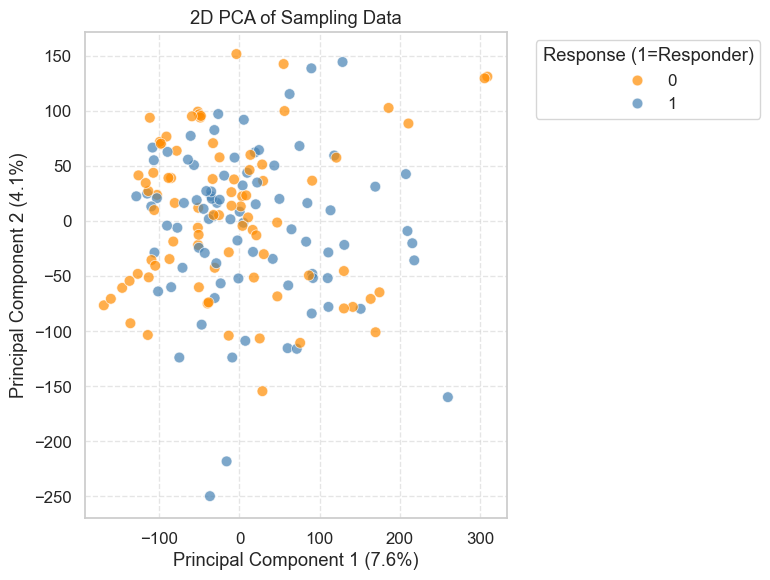

In [29]:
sm =  SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_full, y_nivo)
plot_pca_2d(X_resampled, y_resampled, title="2D PCA of Sampling Data")

# **6. Model Optimization**

We will apply these strategies to optimize model performance. To avoid Data Leakage, all preprocessing steps—including feature selection, data sampling, and dimensionality reduction—must be executed strictly within the cross-validation loop.

To achieve this, the `imblearn` library provides a `Pipeline` module. This allows us to integrate multiple transformations into a single estimator, ensuring that the sampling and reduction techniques are only fitted on the training folds and never "see" the validation data.

In [37]:
# from scikitlearn.ensemble import RandomForestClassifier
logit = LogisticRegression(
            penalty='l2', 
            random_state=42, max_iter=20000)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

pipeline = Pipeline(
    [
    # ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('scaler', MinMaxScaler()),
    # ('feature selector', SelectFromModel(estimator=logit)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ]
) 

scoring = {
    'roc_auc':   'roc_auc',
    'pr_auc':   'average_precision',
    'f1':        'f1',
}

results = {}
cv_results = cross_validate(
                estimator   = pipeline,
                X           = X_pca,
                y           = y_nivo,
                cv          = cv,
                scoring     = scoring,
                n_jobs      = -1,      
                )
print("\n=== Cross‑validation performance (mean ± std) ===")
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    print(f"{metric:25s}  {np.mean(scores):.3f} ± {np.std(scores):.3f}")


=== Cross‑validation performance (mean ± std) ===
roc_auc                    0.639 ± 0.105
pr_auc                     0.757 ± 0.084
f1                         0.741 ± 0.041


In [38]:
pipeline.fit(X_pca, y_nivo)

# y_true_df = pd.read_csv('Data/test_nivo/y_test_labels.csv')
# y_true = y_true_df['Response'].values
y_pred = pipeline.predict(X_pca_test)
y_proba = pipeline.predict_proba(X_pca_test)[:,1]

# print(f"ROC: {roc_auc_score(y_true, y_proba)}")
# print(f"F1 score {f1_score(y_true, y_pred)}")
# print(f"PR AUC: {average_precision_score(y_true, y_proba)}")

ROC AUC:              0.646
F1 score:             0.756
Precision-Recall AUC: 0.712
Optimal threshold:     0.650


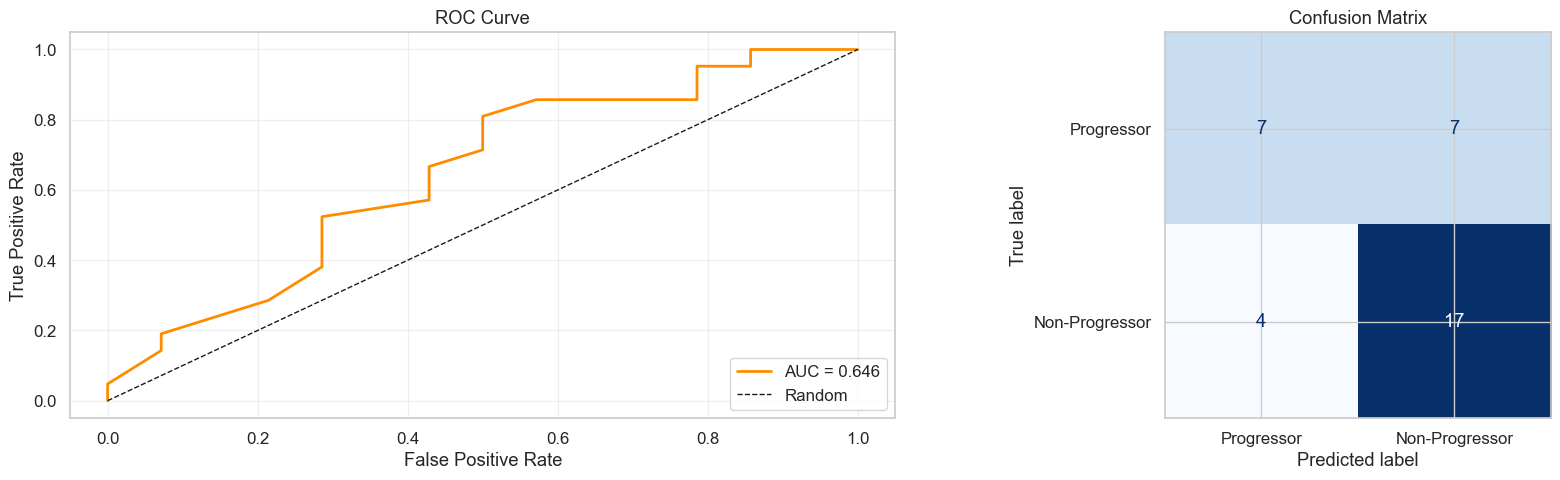

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, average_precision_score,
)



# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc_val = auc(fpr, tpr)

# Optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_val:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Plot 2: Confusion Matrix (at optimal threshold)
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_optimal)
disp = ConfusionMatrixDisplay(cm, display_labels=['Progressor', 'Non-Progressor'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Confusion Matrix')

f1 = f1_score(y_true, y_pred_optimal)
pr_auc = average_precision_score(y_true, y_proba)

print(f'ROC AUC:              {roc_auc_val:.3f}')
print(f'F1 score:             {f1:.3f}')
print(f'Precision-Recall AUC: {pr_auc:.3f}')
print(f'Optimal threshold:     {optimal_threshold:.3f}')

plt.tight_layout()
plt.show()

In [44]:
y_true_df = pd.read_csv('Data/test_nivo/y_test_labels.csv')
y_true = y_true_df['Response'].values

print(f"ROC: {roc_auc_score(y_true, y_proba)}")
print(f"F1 score {f1_score(y_true, y_pred)}")
print(f"PR AUC: {average_precision_score(y_true, y_proba)}")

ROC: 0.6462585034013605
F1 score 0.7636363636363637
PR AUC: 0.7116535399194184


In [45]:
import py_compile
import glob
import shutil

# Compile to bytecode (.pyc) with optimization
py_compile.compile("evaluator.py", optimize=2)

# Copy compiled file from __pycache__ to project root as evaluator.pyc
pyc_files = glob.glob("__pycache__/evaluator.cpython-*.pyc")
if not pyc_files:
    raise FileNotFoundError("No compiled .pyc was generated.")

shutil.copy(pyc_files[0], "evaluator_no_thr.pyc")
print(f"Compiled: {pyc_files[0]} -> evaluator_no_thr.pyc")

Compiled: __pycache__/evaluator.cpython-312.pyc -> evaluator_no_thr.pyc


ROC AUC:              0.646
F1 score:             0.764
Precision-Recall AUC: 0.712


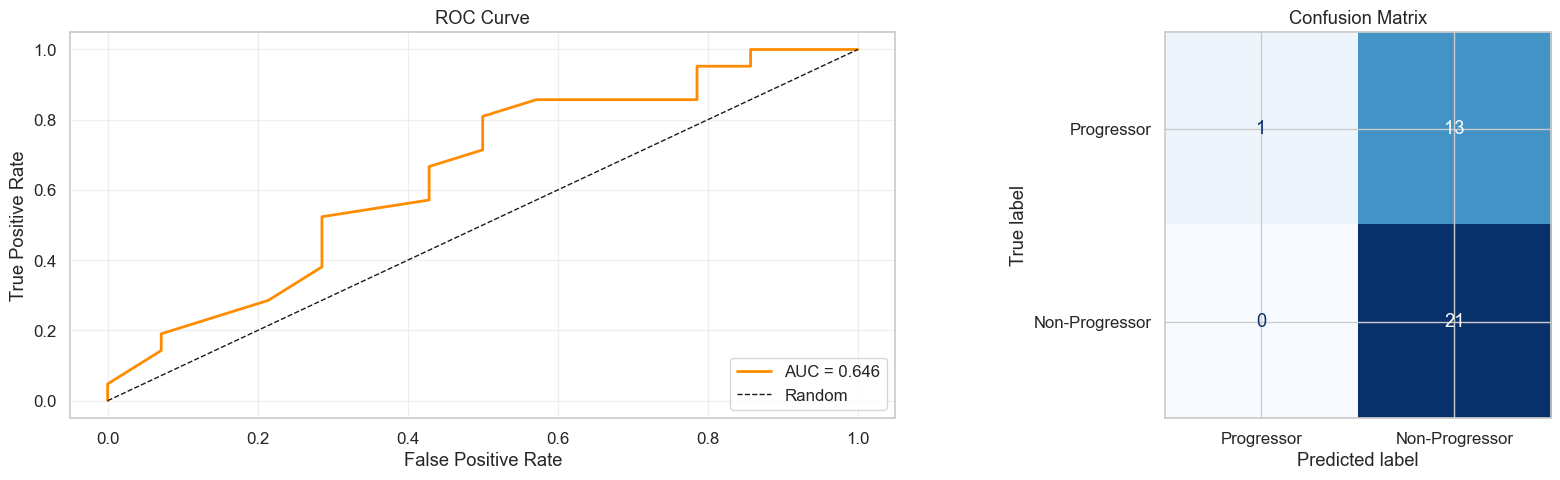

In [52]:
import importlib.machinery, importlib.util

_loader = importlib.machinery.SourcelessFileLoader("evaluator", "evaluator_no_thr.pyc")
_spec = importlib.util.spec_from_loader("evaluator", _loader)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
evaluator = _mod.evaluator

evaluator(y_pred, y_proba)

ROC AUC:              0.646
F1 score:             0.764
Precision-Recall AUC: 0.712
Optimal threshold:    0.650


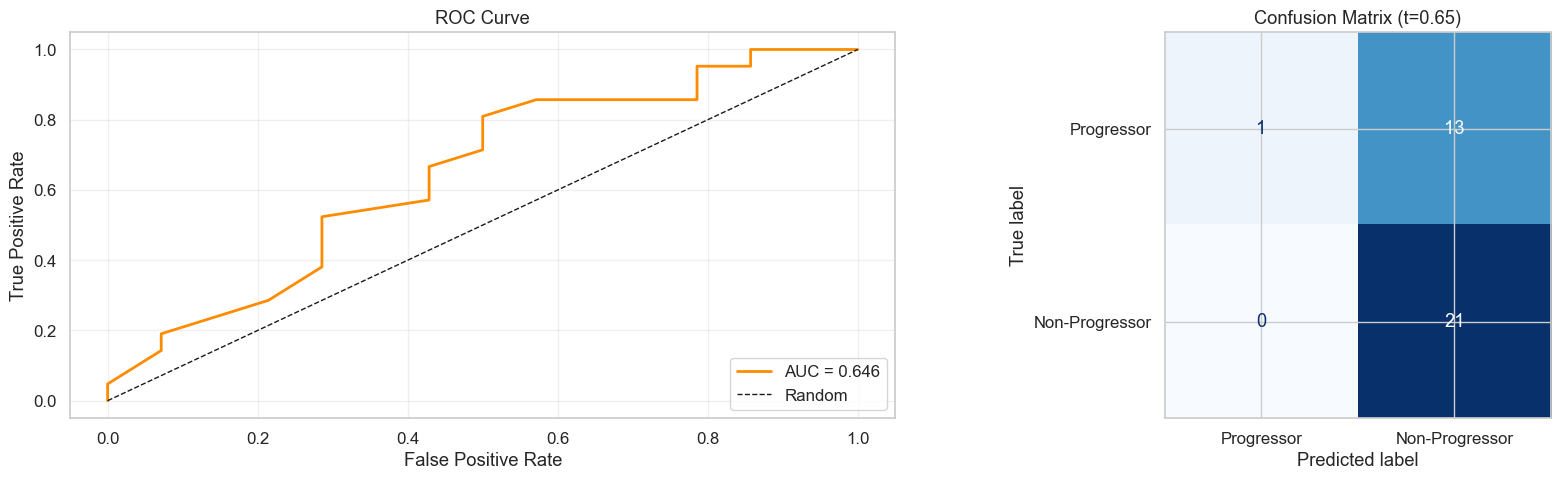

In [ ]:
import importlib.machinery, importlib.util

_loader = importlib.machinery.SourcelessFileLoader("evaluator", "evaluator.pyc")
_spec = importlib.util.spec_from_loader("evaluator", _loader)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
evaluator = _mod.evaluator

evaluator(y_pred, y_proba)

In [ ]:
import importlib.util

# 1. Specify the path to your .pyc file
pyc_path = "evaluator.pyc" 

# 2. Create a module spec from the file location
spec = importlib.util.spec_from_file_location("evaluator", pyc_path)
module = importlib.util.module_from_spec(spec)

# 3. Load (execute) the module
spec.loader.exec_module(module)